# Demo 1: Embedding high-dimensional data in 2D
---

We will use this demo to explore different **dimensionality reduction techniques**.

The goal here is to compare the 2-dimensional map generated by different methods for a database of CHO materials.


In [1]:
import numpy as np
from sklearn import manifold, decomposition
import umap
import cluster_mds as clmds
import matplotlib.pyplot as plt

## 1. Preparing the input
---
### High-dimensional data

We will study a subset of the CHO database from [Chem. Mater. 2022, 34, 14, 6240–6254](https://pubs.acs.org/doi/10.1021/acs.chemmater.1c04279).

Our high-dimensional data corresponds to the SOAP descriptors, whose dimensionality rapidly increases with
$$
\frac{1}{2}\text{NS}\,(\text{NS} + 1)\,(\text{L} + 1)\,,
$$
where
- S: number of species ( `n_species` )
- N: number of radial functions ( `soap n_max` | `soap_turbo alpha_max` )
- L: number of angular functions ( `l_max` )

For the sake of time, we already have the computed descriptors on the file 'desc_cho.dat'.

That said, we will compute them on the second part of the tutorial (demo_2.ipynb).

In [2]:
# load the descriptors and check their dimensionality
desc_cho = np.loadtxt("desc_cho.dat")
dim = np.shape(desc_cho)
print("Number of atomic environments: %i" % dim[0] )
print("Dimensionality of the SOAP descriptors: %i" % (dim[1] - 2) )

# note that the first column corresponds to the atom index in the original database
# and the second column is the chemical species (added for future reference)
Z = desc_cho[:, 1].astype(int)

Number of atomic environments: 1000
Dimensionality of the SOAP descriptors: 2700


### SOAP kernel and kernel distance

Kernel function associated to the SOAP descriptors of atomic environments $i,j$:
$$
K_{ij} = (q_{i}^\text{SOAP}\cdot q_{j}^\text{SOAP})^\zeta
$$
where $\zeta$ can be any positive scalar and $0\leq K_{ij} \leq 1$. 

We can understand the kernel as a similarity measure, where 
$$
K_{ij}=1 \text{  implies  } i = j
$$
$$
K_{ij}=0 \text{  implies  } i\neq j
$$ 

It is always possible to find a dissimilarity measure $\mathbf{D}$ (distance) to a positive definite kernel (like the one above), whose components are defined by:
$$
D_{ij} = \sqrt{1 - K_{ij}}
$$

In [3]:
def compute_kernel(desc, zeta=6, precision=1.e-8):
    L = len(desc)
    K = np.zeros([L,L])
    for i in range(0, L):
        K[i,i] = 1
        for j in range(i + 1, L):
            prod = np.dot(desc[i], desc[j])**zeta
            if prod < precision:
                prod = 0.
            K[i][j] = prod
            K[j][i] = prod
                
    return K

def compute_kernel_distance(desc, precision=1.e-8):
    K = compute_kernel(desc, precision=precision)
    K[(1. - K < precision)] = 0.
    return np.sqrt(1. - K)

In [4]:
%%time
# compute SOAP kernel
K = compute_kernel( desc_cho[:,2:] )
# compute the kernel distance
D = compute_kernel_distance( desc_cho[:,2:] )

CPU times: user 2.18 s, sys: 18.9 ms, total: 2.2 s
Wall time: 2.2 s


## 2. Generating the embeddings
---

Each dimensionality reduction technique follows a different approach to embed the data.

That means that their algorithms are different.

**Difference 1**

- PCA, kPCA and MDS are general dimensionality reduction techniques, where the target low-dimensional space can have dimension N > 2.
- cl-MDS and UMAP were developed with visualization purposes in mind, so N = 2 is implicit in their algorithm.

**Difference 2**

- *Metric-preserving techniques*: PCA, kPCA, MDS and clMDS

- Topology-preserving methods (a.k.a. *manifold unfolding*): UMAP, t-SNE


In [5]:
# Common parameters
# PCA, kPCA, MDS
n_components = 2  #dimension of the target space 
                  #(do not change it, we want 2D visualization)

results = {}

#### Principal Component Analysis (PCA)

In [6]:
%%time
# main parameters
n_runs = 1

# PCA
for m in range(0, n_runs):
    label = 'PCA (n. %i)' % (m + 1)

    method = decomposition.PCA(n_components=n_components)
    results[label] = method.fit_transform(K)

CPU times: user 23.1 ms, sys: 2 µs, total: 23.1 ms
Wall time: 22.8 ms


#### kernel PCA (kPCA)

In [7]:
%%time
# main parameters
n_runs = 1

# kPCA
for m in range(0, n_runs):
    label = 'kPCA (SOAP kernel, n. %i)' % (m + 1)

    method = decomposition.KernelPCA(n_components=n_components, 
                                     kernel="precomputed", 
                                     eigen_solver="auto")
    results[label] = method.fit_transform(K)

CPU times: user 10.9 ms, sys: 0 ns, total: 10.9 ms
Wall time: 10.6 ms


#### Uniform Manifold Approximation and Projection (UMAP)

In [8]:
%%time
# main parameters
n_neigh = [11, 600]  # n. of neighbours  (e.g., 1%, 6%, 60%)

# UMAP
for n in n_neigh:
    label = 'UMAP (n_neigh=%i)' % n
    
    method = umap.UMAP(n_neighbors=n, min_dist=1, metric='precomputed', 
                       init='random')
    results[label] = method.fit_transform(D)

/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
/opt/conda/lib/python3.11/site-packages/umap/umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")


CPU times: user 20.9 s, sys: 401 ms, total: 21.3 s
Wall time: 9.55 s


#### MultiDimensional Scaling (MDS)

In [12]:
%%time
# main parameters
max_iters = [300]
n_inits = [10]

# MDS
for m, n in zip(max_iters, n_inits):
    label = 'MDS (max_iter=%i, n_init=%i)' % (m, n)

    method = manifold.MDS(n_components, init='random', max_iter=m, 
                          n_init=n, metric='precomputed', 
                          normalized_stress='auto')
    results[label] = method.fit_transform(D)

CPU times: user 17.4 s, sys: 127 ms, total: 17.5 s
Wall time: 17.5 s


#### Cluster MDS (cl-MDS)

In [10]:
%%time
# main parameters
n_clusters = [30]

# cl-MDS
for n in n_clusters:
    label = 'cl-MDS (n_clusters=%i)' % n

    method = clmds.clMDS(dist_matrix=D, verbose=False)
    method.cluster_MDS([n, 1], iter_med=100, n_iso_med=2, 
                     n_jobs_cluster=4, n_jobs_anchor=4,
                     n_init_mds_cluster=50, weight_cluster_mds=10, 
                     n_init_mds_anchor=1100, weight_anchor_mds=2)
    results[label] = method.sparse_coordinates

CPU times: user 3.11 s, sys: 214 ms, total: 3.32 s
Wall time: 51.4 s


## 3. Plotting the results

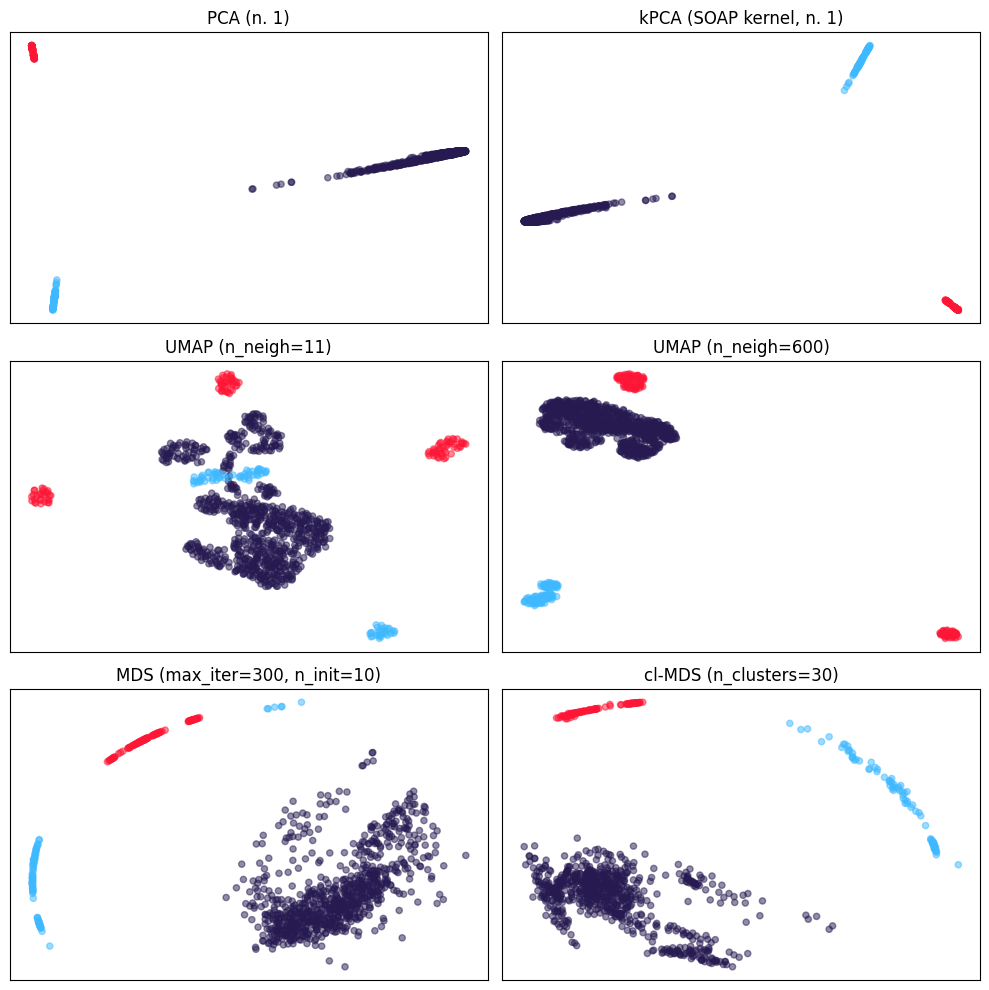

In [13]:
from matplotlib.ticker import NullFormatter

# customize the amount of plots
n_methods = len(results.keys())
n_col = 2
n_row = (n_methods // 2) + (n_methods % 2)

fig, axes = plt.subplots(n_row, n_col, figsize=(10,10))

# colours per chemical species
colour_Z = {'1': tuple(np.array([62, 185,255])/255), 
            '6': tuple(np.array([38,26,81])/255), 
            '8': tuple(np.array([253, 22, 53])/255)} 
list_colours = [colour_Z[str(z)] for z in Z]

for ax, label in zip(axes.ravel(), results.keys()):
    x = results[label][:,0]
    y = results[label][:,1]
    ax.scatter(x, y, c=list_colours, s=20, alpha=0.5)
    ax.set_title(r'%s' % label, fontsize=12)
    ax.xaxis.set_major_formatter(NullFormatter())
    ax.yaxis.set_major_formatter(NullFormatter())
    ax.set_xticks([])
    ax.set_yticks([])
    ax.axis('tight')
    
plt.tight_layout()
plt.show()

## 4. Interpretation of results
---

Food for thought:

1. Do the **axes** carry any meaning? Is it different from one embedding to another?
2. What about general **(Euclidean) distances** in the plots?
3. Can you trust **cluster sizes** and **intercluster distances**?



(continuation of above dicussion, keep it closed)

( stop looking, I see you )

( stop )

( stop, what are you doing )

( I see what you are doing )

S

T

O

O

O

O

O

O

P

P

P

!!!

( okay, I surrender )

( HA! You thought I would surrender so easily )

(   DON'T LOOK YET! )

( Okay, I can sense that you are ready now )

### Answers

1. **The axes have no meaning except for PCA and kPCA**:
    - **PCA, kPCA**: their axes correspond to the two directions of largest variance for the SOAP descriptors/kernels, i.e., x = direction of highest variance, y = directon of second largest variance (orthogonal to x).
    
    
2. In this case, metric-preserving algorithms have the most meaningful distance in their embeddings. However, their meaning can be very different:
    - **MDS, cl-MDS**: focus on distance preservation, i.e., the **2-dim. distances in their plots try to mimic the original kernel distance**.
    - PCA, kPCA: distances related to the original variance/similarity but not straightforward.
    - Local distances can still carry some information in manifold-unfolding algorithms like UMAP (see 3.)
    
3. **Be aware of cluster-like embeddings of topology-related techniques** such as UMAP. Actual cluster distances are arbitrary, which means: cluster shape/size/density and exact distances are unreliable. On the other hand, they can offer a qualitative view of the structure and reliable close neighbours information (very close points correspond to neighbours in SOAP space <---> very similar atomic environments).